## Questão 5

Um determinado circuito elétrico com tensão de entrada $v_i(t)$ e tensão de saída $v_o(t)$ é modelado através da seguinte equação diferencial ordinária:

$$
\frac{d^2v_o(t)}{dt^2}
+ 7\frac{dv_o(t)}{dt}
+ 10v_o(t)
=
\frac{dv_i(t)}{dt}
+ 6v_i(t)
$$

As condições iniciais para esse circuito são:

$$
v_o(0) = 6 \text{ V}
$$

e

$$
\frac{dv_o(0)}{dt} = -4 \text{ V/s}
$$

A entrada é dada por:

$$
x(t) = 6e^{-3t}u(t)
$$

### (a)
Utilizando o método clássico, determine de forma analítica a saída do sistema $y(t)$ para todo $t$.

### (b)

Plote o sinal de saída para:

$$
0 \leq t \leq 2
$$

### (c)

Utilizando computação simbólica, determine a expressão de saída para esse circuito quando a entrada é a mesma da apresentada no item (a). Verifique e compare seu resultado com aquele obtido no item (a).

---

## 3.a. Calculando a saída do sistema y(t) pelo método clássico

**1. Resposta Natural:**

A resposta natural é encontrada resolvendo a EDO homogênea (equação característica $Q(\alpha) = 0$):

$$
\frac{d^2 v_o(t)}{dt^2}+7\frac{dv_o(t)}{dt}+10v_o(t)=0
$$

As raízes características são $\alpha_1 = -5$ e $\alpha_2 = -2$.

A solução natural **geral** (sem aplicar condições iniciais) é, conforme calculado abaixo:

$$
v_o^{(n)}(t) = C_1 e^{-2t} + C_2 e^{-5t}
$$

onde $C_1$ e $C_2$ são constantes arbitrárias que serão determinadas pelas condições iniciais.

In [154]:
import sympy as sp

# Define a variável simbólica e a função
t = sp.symbols('t')
y = sp.Function('v0')

# EDO homogênea (resposta natural): y'' + 7y' + 10y = 0
ode_natural = sp.Eq(sp.diff(y(t), t, 2) + 7*sp.diff(y(t), t) + 10*y(t), 0)

# Resolve a EDO SEM as condições iniciais (solução geral)
solucao_natural_geral = sp.dsolve(ode_natural)
print("Resposta Natural do Sistema (geral):")
print("v0(t) =", solucao_natural_geral.rhs)

# Extrai as raízes da equação característica Q(α) = 0
alfa = sp.symbols('alfa')
eq_caracteristica = alfa**2 + 7*alfa + 10
raizes = sp.solve(eq_caracteristica, alfa)
print("\nRaízes da equação característica Q(α) = 0:")
print("α₁ =", raizes[0], ", α₂ =", raizes[1])


Resposta Natural do Sistema (geral):
v0(t) = (C1 + C2*exp(-3*t))*exp(-2*t)

Raízes da equação característica Q(α) = 0:
α₁ = -5 , α₂ = -2


**3. Resposta Forçada:**

Conforme a **Tabela 2**, para entrada exponencial $e^{\xi t}$ onde $\xi \neq \lambda_i$ (raízes características), a forma da resposta forçada é $\beta e^{\xi t}$.

Para nossa entrada $x(t) = 6e^{-3t}$:
- $\xi = -3$ (não é raiz característica, pois $\alpha_1 = -5$ e $\alpha_2 = -2$)
- Assumimos forma: $y_f(t) = Ae^{-3t}$

Substituindo na EDO completa para encontrar $A$:
$$\frac{d^2y_f}{dt^2} + 7\frac{dy_f}{dt} + 10y_f = \frac{d(6e^{-3t})}{dt} + 6(6e^{-3t})$$

In [155]:
import sympy as sp

t = sp.symbols('t')
A = sp.symbols('A')
y_f = A * sp.exp(-3*t)

# Calcula as derivadas
dy_f = sp.diff(y_f, t)
d2y_f = sp.diff(y_f, t, 2)

print("Suposição: y_f(t) = A*exp(-3*t)")
print("dy_f/dt =", dy_f)
print("d²y_f/dt² =", d2y_f)

# Lado direito da EDO
x = 6*sp.exp(-3*t)
rhs = sp.diff(x, t) + 6*x
print("\nLado direito: dx/dt + 6x =", rhs)

# Monta a equação: d²y_f/dt² + 7*dy_f/dt + 10*y_f = rhs
eq_forçada = sp.Eq(d2y_f + 7*dy_f + 10*y_f, rhs)
print("\nEquação a resolver:", eq_forçada)

# Resolve para A
A_sol = sp.solve(eq_forçada, A)
print("\nSolução para A:", A_sol)

# Forma final da resposta forçada
y_forced = A_sol[0] * sp.exp(-3*t)
print("\nResposta Forçada:")
print("y_f(t) =", y_forced)

Suposição: y_f(t) = A*exp(-3*t)
dy_f/dt = -3*A*exp(-3*t)
d²y_f/dt² = 9*A*exp(-3*t)

Lado direito: dx/dt + 6x = 18*exp(-3*t)

Equação a resolver: Eq(-2*A*exp(-3*t), 18*exp(-3*t))

Solução para A: [-9]

Resposta Forçada:
y_f(t) = -9*exp(-3*t)


logo, a resposta forçada é: 
$v_o^{(f)}(t) = -9e^{-3t}$


**3. Resposta Completa (Natural + Forçada)**

A resposta completa é a soma das respostas:
- **Natural:** $v_o^{(n)}(t) = C_1 e^{-2t} + C_2 e^{-5t}$
- **Forçada:** $v_o^{(f)}(t) = -9e^{-3t}$

A resposta total é $v_o(t) = C_1 e^{-2t} + C_2 e^{-5t} + -9e^{-3t}$


Aplicando as condições iniciais $v_o(0)=6$ e $v_o'(0)=-4$ para determinar $C_1$ e $C_2$.

In [ ]:
# 3.b — Define as condições iniciais e calcula a solução completa (sem plot)

y = sp.Function('y')
condicoes_naturais = {y(0): 6, sp.diff(y(t), t).subs(t, 0): -4}

# Entrada x(t) = 6*exp(-3*t)
x = 6*sp.exp(-3*t)

# Lado direito da EDO: dx/dt + 6*x
rhs = sp.diff(x, t) + 6*x

# EDO completa com a entrada
ode_completa = sp.Eq(sp.diff(y(t), t, 2) + 7*sp.diff(y(t), t) + 10*y(t), rhs)

# Resolve com as mesmas condições iniciais
solucao_completa = sp.dsolve(ode_completa, ics=condicoes_naturais)
print("Resposta Completa do Sistema:")
print("v0(t) =", solucao_completa.rhs)

# Simplifica e expande para forma mais clara
solucao_expandida = sp.expand(solucao_completa.rhs)
print("\nForma expandida:")
print("v0(t) =", solucao_expandida)

**4. Solução Final:**

A resposta completa do sistema para a entrada $x(t)=6e^{-3t}u(t)$ e condições iniciais $v_o(0)=6$, $v_o'(0)=-4$ é:

$$
v_o(t) = \left(\frac{44}{3} - 9e^{-t} + \frac{1}{3}e^{-3t}\right)e^{-2t}
$$

ou na forma expandida:

$$
v_o(t) = \frac{44}{3}e^{-2t} - 9e^{-3t} + \frac{1}{3}e^{-5t}
$$

Para $t < 0$, a saída é nula: $v_o(t) = 0$ (causalidade).

## 3.b. Plotando o sinal de saída para: $$0 \leq t \leq 2$$

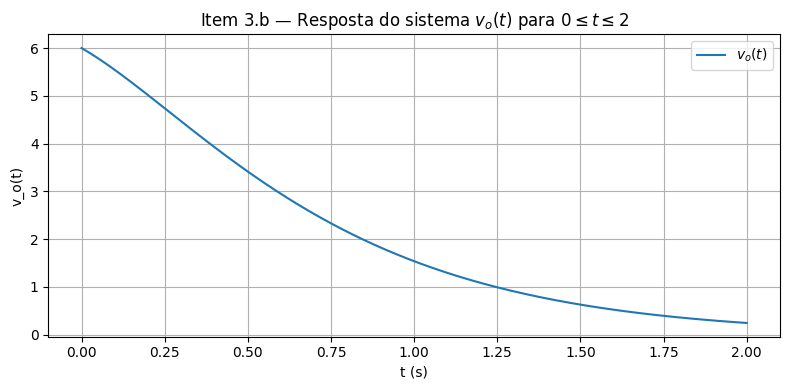

Gráfico salvo em: vo_0_2.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import lambdify

try:
    vo_expr = solucao_expandida
except NameError:
    vo_expr = sp.expand(solucao_completa.rhs)

# Converte para função numérica
vo_num = lambdify(t, vo_expr, 'numpy')

# Pontos de tempo
ts = np.linspace(0, 2, 500)
ys = vo_num(ts)

# Plot
plt.figure(figsize=(8,4))
plt.plot(ts, ys, color='tab:blue', label=r'$v_o(t)$')
plt.xlabel('t (s)')
plt.ylabel('v_o(t)')
plt.title(r'Item 3.b — Resposta do sistema $v_o(t)$ para $0 \leq t \leq 2$')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Salva o gráfico no repositório
fname = 'vo_0_2.png'
plt.savefig(fname, dpi=200)
plt.show()
print('Gráfico salvo em:', fname)